In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import os
from analysis.utils import load_sweep_metadata, load_data, compute_success, chunk_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

In [3]:
from envs.dmcontrol import make_env, make_env_v2

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied



In [4]:
env = make_env_v2('cartpole_swingup')

In [5]:
def wrap_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi


def state_to_x_th(obs_vec):
    """
    obs_vec: [x, cos(th), sin(th), dx, dth]
    returns x, dx, th, dth
    """
    x = float(obs_vec[0])
    cth = float(obs_vec[1])
    sth = float(obs_vec[2])
    dx = float(obs_vec[3])
    dth = float(obs_vec[4])
    th = np.arctan2(sth, cth)
    th = wrap_pi(th)
    return x, dx, th, dth


class OUNoise:

    def __init__(self, theta=0.15, sigma=0.4, mu=0.0, dt=1.0, rng=None):
        self.theta = float(theta)
        self.sigma = float(sigma)
        self.mu = float(mu)
        self.dt = float(dt)
        self.rng = np.random.default_rng() if rng is None else rng
        self.x = 0.0

    def reset(self):
        self.x = 0.0

    def sample(self):
        self.x += self.theta * (self.mu - self.x) * self.dt
        self.x += self.sigma * np.sqrt(self.dt) * float(
            self.rng.standard_normal())
        return self.x


def energy_shaping_u(obs_vec, kE=1.5, kx=0.15, kdx=0.05):
    """
    Heuristic swing-up: pump energy using th, dth; keep cart bounded via x, dx terms.
    """
    x, dx, th, dth = state_to_x_th(obs_vec)

    # energy proxy (dimensionless-ish): 0.5*dth^2 + (1 - cos(th))
    E = 0.5 * (dth**2) + (1.0 - np.cos(th))
    E_des = 2.0

    pump_dir = np.sign(dth * np.cos(th) + 1e-6)
    u = kE * (E_des - E) * pump_dir
    u += -kx * x - kdx * dx
    return float(u)


def pd_upright_u(obs_vec, kp_th=5.0, kd_th=0.8, kp_x=0.2, kd_x=0.1):
    """
    Simple PD around upright th~0 plus small cart centering.
    """
    x, dx, th, dth = state_to_x_th(obs_vec)
    u = -kp_th * th - kd_th * dth - kp_x * x - kd_x * dx
    return float(u)


class DMatchPolicy:
    """
    Episode-level mixture:
      A) OU noise
      B) Kick then OU
      C) Swing-up -> stabilize -> small OU (re-swing if not upright)
    obs_vec must be [x, cos(th), sin(th), dx, dth].
    """

    def __init__(
            self,
            action_low=-1.0,
            action_high=1.0,
            p_mode=(0.50, 0.5),
            ou_theta=0.15,
            ou_sigma_A=0.40,
            ou_sigma_B=0.25,
            ou_sigma_C=0.15,
            kick_steps=(10, 20),
            kick_flip_prob=0.25,
            swingup_steps=(100, 200),
            stabilize_steps=(50, 100),
            upright_theta_thresh=0.35,  # rad
            upright_dtheta_thresh=2.0,  # rad/s
            action_smooth=0.90,  # low-pass; closer to 1 => smoother
            rng=None):
        self.low = float(action_low)
        self.high = float(action_high)
        self.rng = np.random.default_rng() if rng is None else rng

        p = np.asarray(p_mode, dtype=np.float64)
        self.p_mode = p / p.sum()

        self.ou_A = OUNoise(theta=ou_theta, sigma=ou_sigma_A, rng=self.rng)
        self.ou_B = OUNoise(theta=ou_theta, sigma=ou_sigma_B, rng=self.rng)
        self.ou_C = OUNoise(theta=ou_theta, sigma=ou_sigma_C, rng=self.rng)

        self.kick_steps = kick_steps
        self.kick_flip_prob = float(kick_flip_prob)
        self.swingup_steps = swingup_steps
        self.stabilize_steps = stabilize_steps
        self.upright_theta_thresh = float(upright_theta_thresh)
        self.upright_dtheta_thresh = float(upright_dtheta_thresh)

        self.alpha = float(action_smooth)
        self.a_prev = 0.0

        self.mode = None
        self.t = 0
        self.kick_len = 0
        self.kick_sign = 1.0
        self.kick_flip_t = None
        self.swing_len = 0
        self.stab_len = 0

    def reset_episode(self, mode=None):
        self.t = 0
        if mode is None:
            self.mode = int(self.rng.choice([0, 1], p=self.p_mode))
        else:
            self.mode = mode
        self.a_prev = 0.0
        self.ou_A.reset()
        self.ou_B.reset()
        self.ou_C.reset()

        if self.mode == 1:
            self.kick_len = int(
                self.rng.integers(self.kick_steps[0], self.kick_steps[1] + 1))
            self.kick_sign = float(self.rng.choice([-1.0, 1.0]))
            self.kick_flip_t = int(self.rng.integers(1, self.kick_len)) if (
                self.rng.random() < self.kick_flip_prob) else None

        if self.mode == 2:
            self.swing_len = int(
                self.rng.integers(self.swingup_steps[0],
                                  self.swingup_steps[1] + 1))
            self.stab_len = int(
                self.rng.integers(self.stabilize_steps[0],
                                  self.stabilize_steps[1] + 1))

    def act(self, obs_vec):
        if self.mode == 0:
            a = self.ou_A.sample()

        elif self.mode == 1:
            if self.t < self.kick_len:
                sgn = self.kick_sign
                if self.kick_flip_t is not None and self.t >= self.kick_flip_t:
                    sgn = -sgn
                a = sgn
            else:
                a = self.ou_B.sample()

        else:
            # Swing-up -> stabilize -> small OU; re-swing if drifted away
            if self.t < self.swing_len:
                a = energy_shaping_u(obs_vec)
            elif self.t < self.swing_len + self.stab_len:
                a = pd_upright_u(obs_vec)
            else:
                x, dx, th, dth = state_to_x_th(obs_vec)
                if (abs(th) > self.upright_theta_thresh) or (
                        abs(dth) > self.upright_dtheta_thresh):
                    a = energy_shaping_u(obs_vec)
                else:
                    a = self.ou_C.sample()

        # --- ADD CART CENTERING HERE ---
        x, dx, _, _ = state_to_x_th(obs_vec)
        kx, kdx = 0.3, 0.25  # start here; tune
        a = float(a) - kx * x - kdx * dx

        # Low-pass filter + clip
        a = self.alpha * self.a_prev + (1.0 - self.alpha) * float(a)
        self.a_prev = a
        a = float(np.clip(a, self.low, self.high))

        self.t += 1
        return np.array([a], dtype=np.float32)


In [6]:
def collect_dmatch_simple(
    env,
    n_episodes=100,
    max_steps=500,
    seed=0,
    initial_states=[{
        'qpos': {
            'slider': 0.0,
            'hinge_1': 0.0
        },
        'qvel': {
            'slider': 0.0,
            'hinge_1': 0.0
        }
    }],
    n_episodes_per_initial_state=1,
):

    rng = np.random.default_rng(seed)
    policy = DMatchPolicy(
        rng=rng,
        ou_theta=0.05,
        ou_sigma_A=0.20,
        ou_sigma_B=0.25,
        ou_sigma_C=0.15,
        kick_steps=(10, 20),
        kick_flip_prob=0.25,
        action_smooth=0.95,
    )

    episodes = []  # list of episodes; each episode is list of transitions
    for initial_state in initial_states:
        for ep in range(n_episodes_per_initial_state):
            obs = env.reset(initial_state=initial_state)
            policy.reset_episode()

            ep_transitions = []
            for t in range(max_steps):
                act = policy.act(obs)  # behavior action
                obs_next, reward, done, info = env.step(act)

                ep_transitions.append({
                    "obs": obs,  # s_t
                    "action": act.copy(),  # a_t
                    "reward": float(reward) if reward is not None else 0.0,
                    "obs_next": obs_next,  # s_{t+1}
                })

                if done:
                    break

            episodes.append(ep_transitions)

    return episodes


def collect_episode(env,
                    max_steps=500,
                    seed=0,
                    mode=0,
                    save_video=False,
                    out_path=None,
                    width=128,
                    height=128,
                    initial_state=None):
    obs, actions, rewards, frames = [], [], [], []

    rng = np.random.default_rng(seed)
    obs_ = env.reset(initial_state=initial_state)
    obs.append(obs_)
    policy = DMatchPolicy(
        rng=rng,
        ou_theta=0.05,
        ou_sigma_A=0.20,
        ou_sigma_B=0.25,
        ou_sigma_C=0.15,
        kick_steps=(10, 20),
        kick_flip_prob=0.25,
        action_smooth=0.95,
    )
    policy.reset_episode(mode=mode)

    if save_video:
        frames.append(env.env.render(height=height, width=width))

    for t in range(max_steps - 1):
        act = policy.act(obs_)  # behavior action
        obs_, reward, done, info = env.step(act)
        obs.append(obs_)
        actions.append(act)
        rewards.append(reward)

        if save_video:
            frames.append(env.env.render(height=height, width=width))

    episode = {
        "obs": np.array(obs),
        "actions": np.array(actions),
        "rewards": np.array(rewards),
        "frames": frames,
    }
    return episode

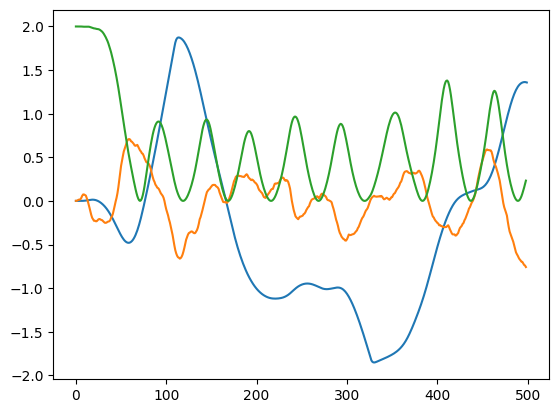

In [7]:
episode_data = collect_episode(
    env,
    max_steps=500,
    seed=0,
    mode=0,
    save_video=True,
    out_path="episode.mp4",
    width=384,
    height=384,
    initial_state={
        'qpos': {
            'slider': 0,  # cart position
            'hinge_1': 0.0,  # pole angle
        },
        'qvel': {
            'slider': 0.0,  # cart velocity
            'hinge_1': 0.0,  # pole angular velocity
        },
    })
obs = episode_data["obs"]
actions = episode_data["actions"]
rewards = episode_data["rewards"]

plt.plot(obs[:, 0])
plt.plot(actions)
plt.plot(rewards)

In [8]:
import imageio
import os

# Create output directory if it doesn't exist
output_dir = "videos_130126"
os.makedirs(output_dir, exist_ok=True)

# Save frames to video
video_path = os.path.join(output_dir, "episode.mp4")
imageio.mimsave(video_path, episode_data["frames"], fps=30)
print(f"Video saved to: {video_path}")

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/imageio_ffmpeg/_utils.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Video saved to: videos_130126/episode.mp4


In [9]:
#Example usage:

initial_positions = [-1, 0, 1]
initial_angles = np.radians(np.linspace(0, 360, 5))

initial_states = []
for initial_position in initial_positions:
    for initial_angle in initial_angles:
        initial_states.append(
            {
                'qpos': {
                    'slider': initial_position,
                    'hinge_1': initial_angle,
                },
                'qvel': {
                    'slider': 0.0,
                    'hinge_1': 0.0
                }
            },)

episodes = collect_dmatch_simple(env,
                                 n_episodes=10,
                                 max_steps=500,
                                 seed=1,
                                 initial_states=initial_states,
                                 n_episodes_per_initial_state=1)
print(len(episodes), len(episodes[0]), episodes[0][0]["obs"])


15 500 tensor([-1.,  1.,  0.,  0.,  0.])


In [10]:
obs_episodes = []
rewards_episodes = []
actions_episodes = []
for j in range(len(episodes)):
    obs_episode = np.array([episodes[j][i]['obs_next'] for i in range(500)])
    actions_episode = np.array([episodes[j][i]['action'] for i in range(500)])
    rewards_episode = np.array([episodes[j][i]['reward'] for i in range(500)])
    obs_episodes.append(obs_episode)
    rewards_episodes.append(rewards_episode)
    actions_episodes.append(actions_episode)
obs_episodes_stacked = np.concatenate(obs_episodes, axis=0)

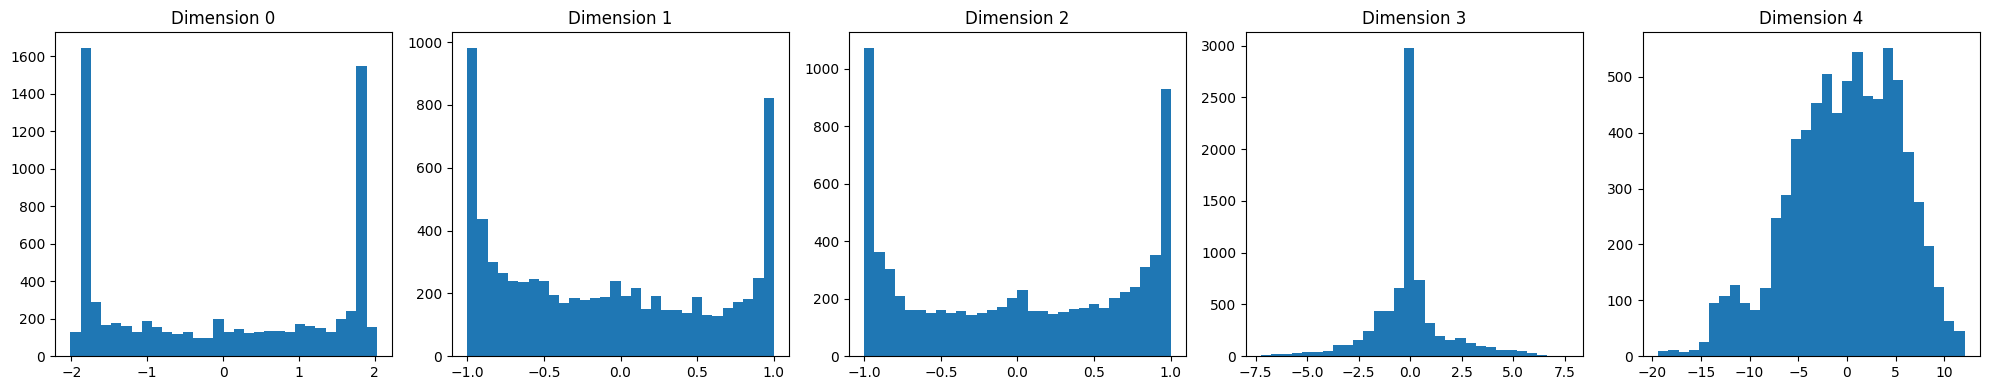

In [11]:
n_dims = obs_episodes_stacked.shape[1]
fig, axes = plt.subplots(1, n_dims, figsize=(4 * n_dims, 4))
for i in range(n_dims):
    axes[i].hist(obs_episodes_stacked[:, i], bins=30)
    axes[i].set_title(f'Dimension {i}')
plt.tight_layout()
plt.show()

## Convert observations to activations

In [12]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

sys.path.insert(0, '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2')
from tdmpc2 import TDMPC2
from tqdm import tqdm
from envs import make_env
from hydra import initialize, compose
from omegaconf import OmegaConf
from common.parser import parse_cfg
from common.seed import set_seed

## TDMPC2

In [13]:
# Base configuration
CKPT_TO_USE = 500_000
CKPT_PATH = f'logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/{CKPT_TO_USE}.pt'
#CKPT_PATH = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpole-swingup-noncentered.pt'
override_cfg = dict(
    task='cartpole-swingup',
    checkpoint=CKPT_PATH,
    obs='state',
    seed=0,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
    save_video=False,  # Disable video to speed up sweep
    record_planning=False,  # Focus on episode data
)

with initialize(config_path="tdmpc2", version_base=None):
    cfg = compose(config_name="config")
    OmegaConf.set_struct(cfg, False)
    cfg = OmegaConf.merge(cfg, override_cfg)

# Parse config
cfg = parse_cfg(cfg)
set_seed(cfg.seed)

cfg.initial_state = {
    'qpos': {
        'slider': 0,  #cart position
        'hinge_1': 0,  # pole angle
    },
}

env_fake = make_env(cfg)

print("\nLoading agent...")
agent_tdmpc2 = TDMPC2(cfg)

# Optionally load checkpoint
if hasattr(cfg, 'checkpoint') and cfg.checkpoint:
    print(f"Loading checkpoint: {cfg.checkpoint}")
    agent_tdmpc2.load(cfg.checkpoint)


Loading agent...
Episode length: 500
Discount factor: 0.99
Loading checkpoint: logs/model-runs/2025-12-20/19-10-12/cartpole_exp/models/500000.pt


In [14]:
from common.activation_patcher import ActivationPatcher

In [ ]:
#patcher.remove_hooks()

Setting up hooks for encoder_output
Setting up hooks for dynamics_output
ActivationPatcher initialized with hooks on:
  - encoder_output
  - dynamics_output
  - encoder_layers/*
  - dynamics_layers/*
Removed all hooks


In [52]:
def get_activations_tdmpc2(agent, obs_episode, patcher):

    all_steps = []

    for t, obs in enumerate(obs_episode):
        with torch.no_grad():
            action, chosen_idx, elite_value = agent.act(
                torch.from_numpy(obs).cuda(),
                t0=(t == 0),
                eval_mode=True,
                task=None,
                return_indices=True,
            )

        acts = patcher.get_all_activations()

        step = {
            "action": action.detach().cpu(),
            "chosen_idx": chosen_idx.detach().cpu(),
            "elite_value": elite_value.detach().cpu(),
            "all": {
                k: v.detach().cpu().clone() for k, v in acts.items()
            },
        }

        # store chosen rollout activations for dynamics layers
        for k, v in acts.items():
            if k.startswith("dynamics_layer/"):
                step['all'][f"{k}/chosen"] = v[chosen_idx].detach().cpu()

        all_steps.append(step)

    num_steps = len(all_steps)

    activations = {
        'encoder_1':
            np.array([
                all_steps[i]['all']['encoder_layer/state/0']
                for i in range(num_steps)
            ]).squeeze(),
        'encoder_2':
            np.array([
                all_steps[i]['all']['encoder_layer/state/1']
                for i in range(num_steps)
            ]).squeeze(),
        'dynamics_1':
            np.array([
                all_steps[i]['all']['dynamics_layer/0/chosen']
                for i in range(num_steps)
            ]).squeeze(),
        'dynamics_2':
            np.array([
                all_steps[i]['all']['dynamics_layer/1/chosen']
                for i in range(num_steps)
            ]),
        'dynamics_3':
            np.array([
                all_steps[i]['all']['dynamics_layer/2/chosen']
                for i in range(num_steps)
            ]).squeeze(),
    }

    return activations, all_steps


In [53]:
# Create patcher once
patcher = ActivationPatcher(
    agent_tdmpc2.model,
    modules_to_hook=[],
    hook_encoder_layers=True,
    hook_dynamics_layers=True,
)

activations_tdmpc2 = []
for ep in tqdm(obs_episodes):
    acts, all_steps = get_activations_tdmpc2(agent_tdmpc2, ep, patcher=patcher)
    activations_tdmpc2.append(acts)


ActivationPatcher initialized with hooks on:
  - encoder_layers/*
  - dynamics_layers/*


100%|██████████| 15/15 [04:55<00:00, 19.68s/it]


In [60]:
encoder_1_all = [
    activations_tdmpc2[i]['encoder_1'] for i in range(len(activations_tdmpc2))
]
encoder_2_all = [
    activations_tdmpc2[i]['encoder_2'] for i in range(len(activations_tdmpc2))
]
dynamics_1_all = [
    activations_tdmpc2[i]['dynamics_1'] for i in range(len(activations_tdmpc2))
]
dynamics_2_all = [
    activations_tdmpc2[i]['dynamics_2'] for i in range(len(activations_tdmpc2))
]
dynamics_3_all = [
    activations_tdmpc2[i]['dynamics_3'] for i in range(len(activations_tdmpc2))
]

In [65]:
print("encoder_1_all shape:", encoder_1_all[0].shape)
print("encoder_2_all shape:", encoder_2_all[0].shape)
print("dynamics_1_all shape:", dynamics_1_all[0].shape)
print("dynamics_2_all shape:", dynamics_2_all[0].shape)
print("dynamics_3_all shape:", dynamics_3_all[0].shape)


encoder_1_all shape: (500, 256)
encoder_2_all shape: (500, 512)
dynamics_1_all shape: (500, 512)
dynamics_2_all shape: (500, 512)
dynamics_3_all shape: (500, 512)


## Decoding

In [66]:
vars_all = {
    'encoder_1_all':
        encoder_1_all,
    'encoder_2_all':
        encoder_2_all,
    'dynamics_1_all':
        dynamics_1_all,
    'dynamics_2_all':
        dynamics_2_all,
    'dynamics_3_all':
        dynamics_3_all,
    'obs': [obs_episode for obs_episode in obs_episodes],
    'position': [
        obs_episode[:, 0].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'cos(pole_angle)': [
        obs_episode[:, 1].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'sin(pole_angle)': [
        obs_episode[:, 2].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'cart_velocity': [
        obs_episode[:, 3].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'pole_angular_velocity': [
        obs_episode[:, 4].reshape(-1, 1) for obs_episode in obs_episodes
    ],
    'rewards': [
        rewards_episode.reshape(-1, 1) for rewards_episode in rewards_episodes
    ],
    'actions': [
        actions_episode.reshape(-1, 1) for actions_episode in actions_episodes
    ],
}

In [62]:
import os
import pickle

# Save vars_all to disk
save_path = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data'
os.makedirs(save_path, exist_ok=True)

with open(os.path.join(save_path, 'vars_all_tdmpc2_perlayer.pkl'), 'wb') as f:
    pickle.dump(vars_all, f)

print(f"Saved vars_all to {save_path}")


Saved vars_all to /home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data


In [67]:
decoding_relationships = [
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
]

for x_var in [
        'encoder_1_all', 'encoder_2_all', 'dynamics_1_all', 'dynamics_2_all',
        'dynamics_3_all'
]:
    for y_var in [
            'position', 'cos(pole_angle)', 'sin(pole_angle)', 'cart_velocity',
            'pole_angular_velocity', 'rewards', 'actions'
    ]:
        decoding_relationships.append((x_var, y_var))

In [ ]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data_tdmpc2_perlayer'
#path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/analysis/'
#'sac': vars_sac,

for model in ['linear_regression']:
    for predict_type in [
            'future',
            'difference',
    ]:
        results_decoding = {}
        for x_var, y_var in decoding_relationships:
            print(f"Decoding {x_var} -> {y_var}")
            results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
                vars_all[x_var],
                vars_all[y_var],
                model=model,
                lags=np.arange(-80, 81, 10),
                k_holdout=1,
                add_bootstrap_ci=True,
                shuffle_X=False,
                shuffle_y=False,
                predict_difference=True
                if predict_type == 'difference' else False,
                standardize_X=True
            )  #NOTE: I'm standardizing the X data, but not the y data

        #Save results_decoding to pickle file
        with open(
                os.path.join(
                    path_to_save,
                    f'results_decoding_{predict_type}_{model}_passive_data.pkl'
                ), 'wb') as f:
            pickle.dump(results_decoding, f)

In [69]:
import pickle

with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data_tdmpc2_perlayer/results_decoding_future_linear_regression_passive_data.pkl',
        'rb') as f:
    results_decoding_future = pickle.load(f)

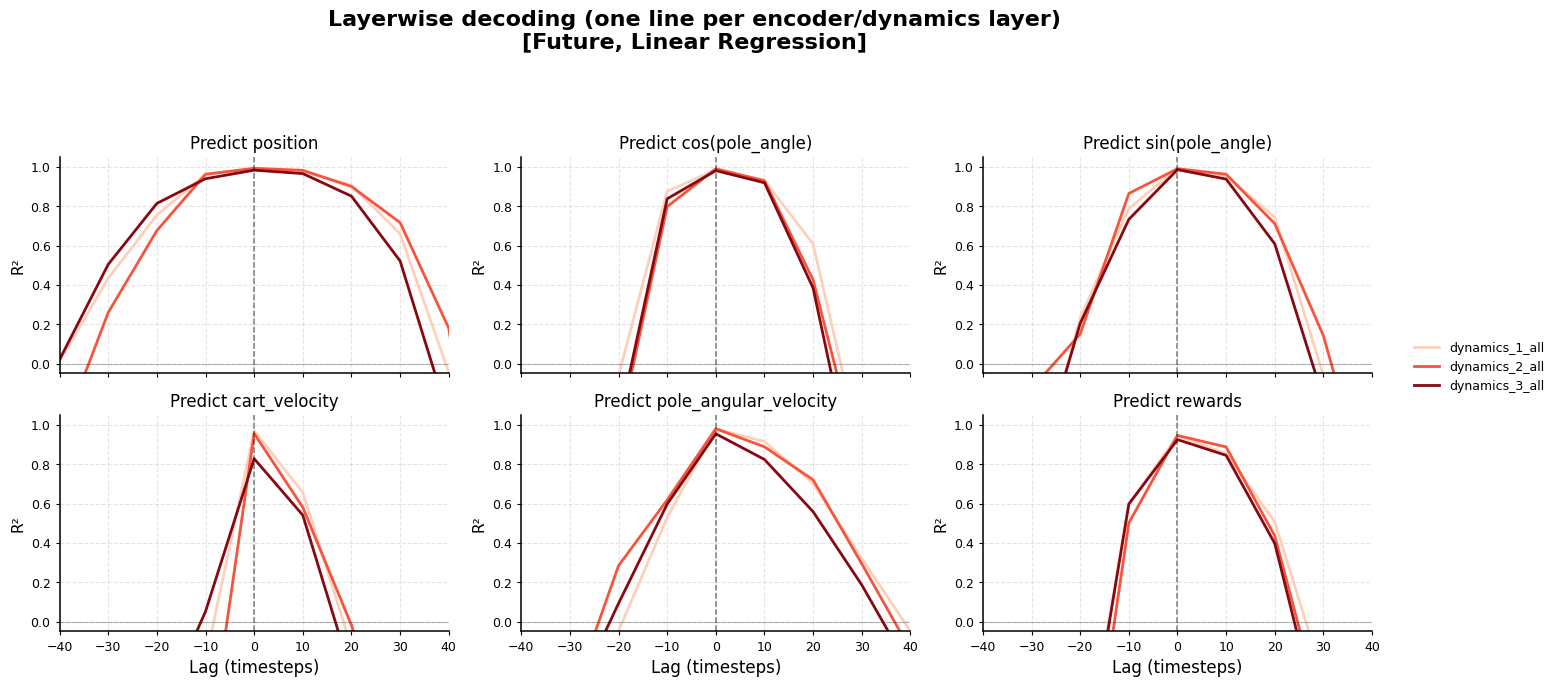

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Plot: one line per encoder layer, each y-variable in its own subplot

# The encoder layers of interest as per lines 11-18 in the notebook
layer_variables = [
    'encoder_1_all', 'encoder_2_all', 'dynamics_1_all', 'dynamics_2_all',
    'dynamics_3_all'
]

layer_variables = ['dynamics_1_all', 'dynamics_2_all', 'dynamics_3_all']

# Create a red colormap (light to dark) for encoding/dynamics layers
cmap = plt.get_cmap('Reds')
num_layers = len(layer_variables)
layer_colors = [
    cmap(0.18 + 0.75 * i / (num_layers - 1)) for i in range(num_layers)
]
layer_color_map = dict(zip(layer_variables, layer_colors))

y_variables = [
    'position',
    'cos(pole_angle)',
    'sin(pole_angle)',
    'cart_velocity',
    'pole_angular_velocity',
    'rewards',
]

n_vars = len(y_variables)
nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 6.5), sharex=True)
axes = axes.flatten()  # Make it easy to index as a 1D list

regression_type = 'future'
model = 'linear_regression'

# To collect handles/labels for external legend
handles_labels = None

for idx, y_var in enumerate(y_variables):
    ax = axes[idx]
    # For external legend: only grab handles/labels from first subplot
    handles_this_ax, labels_this_ax = None, None
    for ilayer, layer in enumerate(layer_variables):
        key = f'{layer}-{y_var}'
        if key in results_decoding_future:
            results = results_decoding_future[key]
            r2_mean = results['r2_mean']
            r2_ci = results['r2_ci']
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())
            ci_lower = [r2_ci[lag][0] for lag in lags]
            ci_upper = [r2_ci[lag][1] for lag in lags]
            color = layer_color_map.get(layer, None)
            line, = ax.plot(lags, means, label=layer, linewidth=2, color=color)
            #ax.fill_between(lags, ci_lower, ci_upper, alpha=0.15, color=color)
            # collect handles/labels from first subplot/layer combo
            if idx == 0:
                if handles_this_ax is None:
                    handles_this_ax, labels_this_ax = [], []
                handles_this_ax.append(line)
                labels_this_ax.append(layer)
    ax.set_ylabel('R²', fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-40, 40)
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.1)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.25, linewidth=0.8)
    ax.set_title(f'Predict {y_var}', fontsize=12)
    ax.grid(alpha=0.32, linestyle='--')
    ax.tick_params(labelsize=9, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)
    # Collect legend handles/labels from first axis
    if idx == 0 and handles_this_ax is not None:
        handles_labels = (handles_this_ax, labels_this_ax)

# Set xlabel for the bottom row axes
for col in range(ncols):
    axes[ncols + col].set_xlabel('Lag (timesteps)', fontsize=12)
fig.suptitle(
    f'Layerwise decoding (one line per encoder/dynamics layer)\n[{regression_type.capitalize()}, {model.replace("_", " ").title()}]',
    fontsize=16,
    fontweight='bold',
    y=1.05)

# Place the legend outside of the plot area (to the right)
if handles_labels is not None:
    fig.legend(handles_labels[0],
               handles_labels[1],
               fontsize=9,
               loc='center left',
               bbox_to_anchor=(1.01, 0.5),
               frameon=False,
               borderaxespad=0)

plt.tight_layout(rect=[0, 0, 1, 0.97])
sns.despine()
plt.show()